# Epinet

In [1]:
%%capture
%pip install git+https://github.com/lightning-uq-box/lightning-uq-box.git

## Theoretic Foundation

An *epistemic neural network* (ENN), introduced by [Osband et al., 2023](https://arxiv.org/abs/2107.08924), is a pair: a function class $f_\theta(x, z)$ and a reference distribution $P_Z$ over an **epistemic index** $z$. Where a conventional network maps an input to a single prediction, an ENN maps an input *and an index* to a prediction, and integrating over $z \sim P_Z$ recovers a predictive distribution.

What this buys is *joint* predictions. Most UQ methods are evaluated one input at a time, on marginal predictions $\hat{P}(y_t \mid x_t)$. But many downstream uses — sequential decision making, active learning, bandits — depend on how predictions at *different* inputs covary, which the marginals cannot express. An ENN's joint prediction over $\tau$ inputs is

$$\hat{P}_{1:\tau}(y_{1:\tau}) = \int P_Z(dz) \prod_{t=1}^{\tau} \mathrm{softmax}(f_\theta(x_t, z))_{y_t},$$

where the shared $z$ inside the product is what ties the predictions together.

The **epinet** is a particular, cheap way of building one. Rather than a new architecture, it is a small head bolted onto a conventional base network $\mu_\zeta(x)$:

$$f_\theta(x, z) = \mu_\zeta(x) + \sigma_\eta(\mathrm{sg}[\phi_\zeta(x)], z),$$

where $\phi_\zeta(x)$ are features of the base network's last hidden layer and $\mathrm{sg}[\cdot]$ is a stop-gradient: the epinet reads the base network's features but never sends gradients back through them. The epinet itself splits into a learnable part and a *fixed* part,

$$\sigma_\eta(\tilde{x}, z) = \sigma^L_\eta(\tilde{x}, z) + \sigma^P(\tilde{x}, z), \qquad \sigma^L_\eta(\tilde{x}, z) := \mathrm{mlp}_\eta([\tilde{x}, z])^T z.$$

The learnable part is an MLP whose output is reshaped to $\mathbb{R}^{D_Z \times C}$ and contracted with the index. The fixed part $\sigma^P$ is a frozen, randomly initialized *prior function*. It is never trained, and it is what supplies uncertainty where the data does not pin the model down: away from the training data nothing pulls the learnable part toward cancelling it, so the prior's variation across $z$ survives as predictive spread.

Two properties make this practical. Because the base network is only read, never modified, an epinet can be attached to a **large pretrained network whose weights stay frozen** — the paper's headline result is an epinet beating a 100-particle deep ensemble on ImageNet joint log-loss at less than the cost of two particles. And because only the small head sees the index, averaging the loss over many index draws costs one base forward pass, not many.

## Imports

In [2]:
import os
import tempfile
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import torch
from lightning import Trainer
from lightning.pytorch import seed_everything
from lightning.pytorch.loggers import CSVLogger
from torch import nn
from torch.optim import Adam

from lightning_uq_box.datamodules import TwoMoonsDataModule
from lightning_uq_box.eval_utils import joint_log_loss_dyadic, marginal_log_loss
from lightning_uq_box.models import MLP
from lightning_uq_box.uq_methods import EpinetClassification
from lightning_uq_box.viz_utils import (
    plot_predictions_classification,
    plot_training_metrics,
    plot_two_moons_data,
)

torch.set_num_threads(1)
plt.rcParams["figure.figsize"] = [14, 5]

In [3]:
seed_everything(0)

Seed set to 0


0

We define a temporary directory to look at some training metrics and results.

In [4]:
my_temp_dir = tempfile.mkdtemp()

## Datamodule

We use the Two Moons dataset, a two-dimensional binary classification problem. Its appeal here is that the input space is small enough to visualize completely, so we can see exactly where the model is and is not confident.

In [5]:
dm = TwoMoonsDataModule(batch_size=128)

X_train, Y_train, X_test, Y_test, test_grid_points = (
    dm.X_train,
    dm.Y_train,
    dm.X_test,
    dm.Y_test,
    dm.test_grid_points,
)

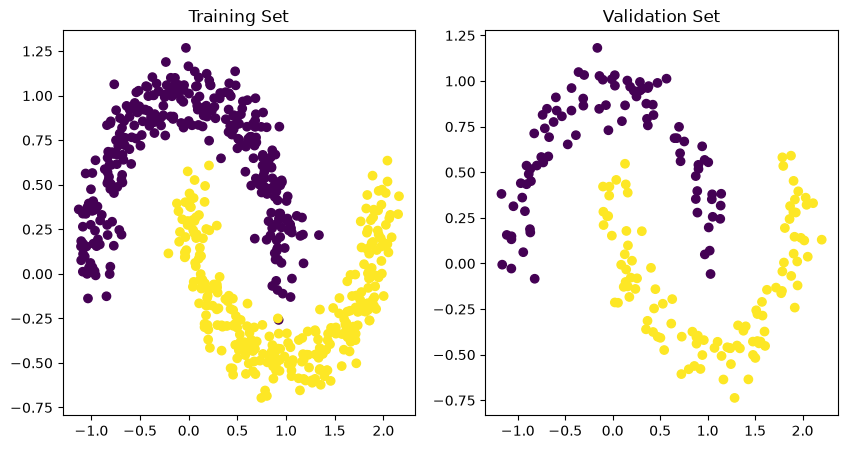

In [6]:
fig = plot_two_moons_data(X_train, Y_train, X_test, Y_test)

## Model

As in the regression case we begin with an ordinary base network, which the epinet will read from without modifying.

In [7]:
network = MLP(n_inputs=2, n_hidden=[50, 50], n_outputs=2, activation_fn=nn.ReLU())
network

MLP(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=50, out_features=2, bias=True)
  )
)

`EpinetClassification` wraps it. The loss is the ordinary cross-entropy: the epinet needs no special loss function, because averaging the standard loss over sampled indices is exactly what the paper prescribes.

In [8]:
epinet_module = EpinetClassification(
    model=network,
    optimizer=partial(Adam, lr=1e-2),
    loss_fn=nn.CrossEntropyLoss(),
    task="multiclass",
    index_dim=8,
    num_index_samples=8,
    num_pred_samples=100,
    epinet_hidden_dims=[15, 15],
    prior_hidden_dims=[5, 5],
    epi_prior_scale=0.0,
    input_prior_scale=3.0,
)

## Trainer

In [9]:
logger = CSVLogger(my_temp_dir)
trainer = Trainer(
    accelerator="cpu",
    max_epochs=100,  # number of epochs we want to train
    logger=logger,  # log training metrics for later evaluation
    log_every_n_steps=1,
    enable_checkpointing=False,
    enable_progress_bar=False,
    default_root_dir=my_temp_dir,
)

In [10]:
trainer.fit(epinet_module, dm)


  | Name          | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | model         | MLP              | 2.8 K  | train | 0    
1 | loss_fn       | CrossEntropyLoss | 0      | train | 0    
2 | train_metrics | MetricCollection | 0      | train | 0    
3 | val_metrics   | MetricCollection | 0      | train | 0    
4 | test_metrics  | MetricCollection | 0      | train | 0    
5 | epinet        | Epinet           | 3.3 K  | train | 0    
-------------------------------------------------------------------
4.2 K     Trainable params
1.9 K     Non-trainable params
6.1 K     Total params
0.024     Total estimated model params size (MB)
29        Modules in train mode
57        Modules in eval mode
0         Total Flops


`Trainer.fit` stopped: `max_epochs=100` reached.


## Training Metrics

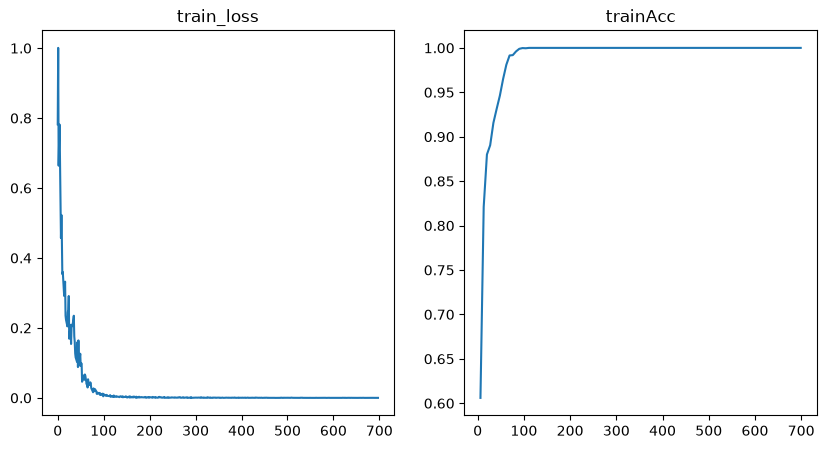

In [11]:
fig = plot_training_metrics(
    os.path.join(my_temp_dir, "lightning_logs"), ["train_loss", "trainAcc"]
)

## Prediction

In [12]:
# save predictions
trainer.test(epinet_module, dm.test_dataloader())

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         testAcc                    1.0
     testCalibration       0.0006211852887645364
 testEmpirical Coverage             1.0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'testAcc': 1.0,
  'testCalibration': 0.0006211852887645364,
  'testEmpirical Coverage': 1.0}]

In [13]:
preds = epinet_module.predict_step(test_grid_points.to(epinet_module.device))

## Evaluate Predictions

Evaluating over the full input grid shows where the epinet is uncertain. The uncertainty should be low along the two moons, where the training data pins the model down, and rise in the gap between them and away from the data entirely.

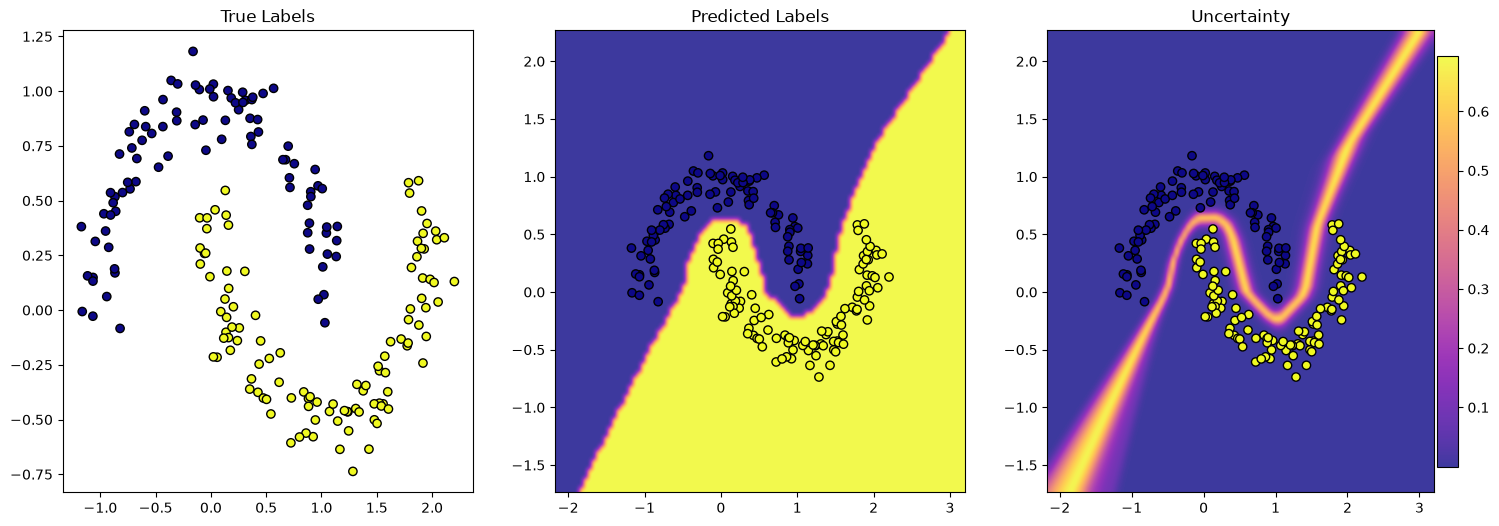

In [14]:
fig = plot_predictions_classification(
    X_test, Y_test, preds["pred"].argmax(-1), test_grid_points, preds["pred_uct"]
)

## Joint Predictions

Everything so far has been a *marginal* evaluation: each point scored on its own. The point of an ENN is the *joint* prediction, and the box ships the metrics to measure it.

The distinction is easiest to see by drawing the individual index samples, exactly as the regression tutorial draws its sample functions. Each $z$ gives a different classifier; where the data pins the model down the boundaries agree, and where it does not they fan out.


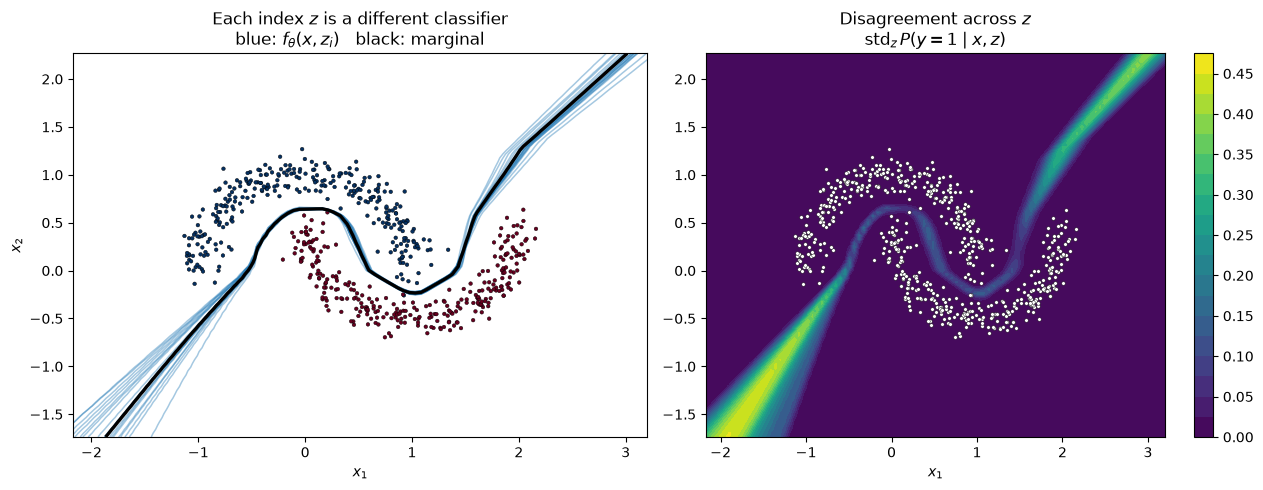

In [15]:
samples = preds["logits"].permute(2, 0, 1).softmax(-1)[..., 1].cpu().numpy()
side = int(np.sqrt(test_grid_points.shape[0]))
xs = test_grid_points[:, 0].reshape(side, side).cpu().numpy()
ys = test_grid_points[:, 1].reshape(side, side).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i in range(20):
    ax.contour(
        xs, ys, samples[i].reshape(side, side),
        levels=[0.5], colors="C0", alpha=0.4, linewidths=1.1,
    )
ax.contour(
    xs, ys, samples.mean(0).reshape(side, side),
    levels=[0.5], colors="k", linewidths=2.4,
)
ax.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, cmap="RdBu_r", s=7,
           edgecolor="k", linewidth=0.3)
ax.set_xlim(xs.min(), xs.max())
ax.set_ylim(ys.min(), ys.max())
ax.set_title("Each index $z$ is a different classifier\nblue: $f_\\theta(x, z_i)$   black: marginal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

ax = axes[1]
m = ax.contourf(xs, ys, samples.std(0).reshape(side, side), levels=20, cmap="viridis")
ax.scatter(X_train[:, 0], X_train[:, 1], c="w", s=7, edgecolor="k", linewidth=0.3)
plt.colorbar(m, ax=ax)
ax.set_title("Disagreement across $z$\n$\\mathrm{std}_z\\,P(y{=}1 \\mid x, z)$")
ax.set_xlabel("$x_1$")
plt.tight_layout()
plt.show()

The left panel is the whole idea: the epinet does not merely widen its error bars near the boundary, it produces *a set of coherent alternative classifiers*. A marginal metric cannot see the difference, because averaging those samples gives the same per-point probabilities either way.

`marginal_log_loss` collapses the index samples into one predictive distribution per input and scores each independently. `joint_log_loss_dyadic` keeps the samples tied across a batch of $\tau$ inputs and scores the batch as a whole, drawing those batches by **dyadic sampling** ([Appendix F](https://arxiv.org/abs/2107.08924)): pick $\kappa$ anchor points, then resample $\tau$ points from just those anchors.

With $\kappa = 2$ and $\tau = 10$, a batch contains only two *distinct* inputs, each repeated about five times. So the metric is asking a sharp question: **when you see the same input five times, do your five predictions agree with each other?** Plotting one such batch makes the mechanism concrete.

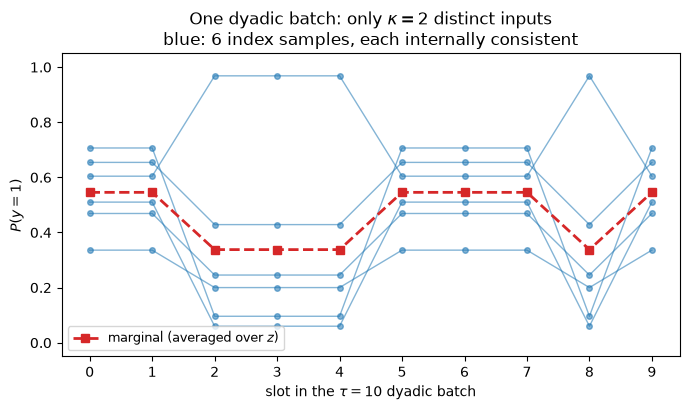

In [16]:
from lightning_uq_box.eval_utils.joint_prediction import dyadic_batch_indices

boundary = torch.topk(preds["pred_uct"], 200).indices
boundary_logits = preds["logits"][boundary].permute(2, 0, 1).cpu()
boundary_probs = boundary_logits.softmax(-1)

batch = dyadic_batch_indices(200, tau=10, kappa=2, generator=torch.Generator().manual_seed(3))

fig, ax = plt.subplots(figsize=(7, 4.2))
for row in range(6):
    ax.plot(range(10), boundary_probs[row, batch, 1], "o-", color="C0",
            alpha=0.55, ms=4, lw=1)
ax.plot(range(10), boundary_probs.mean(0)[batch, 1], "s--", color="C3", lw=2,
        ms=6, label="marginal (averaged over $z$)")
ax.set_xticks(range(10))
ax.set_xlabel("slot in the $\\tau=10$ dyadic batch")
ax.set_ylabel("$P(y{=}1)$")
ax.set_ylim(-0.05, 1.05)
ax.set_title("One dyadic batch: only $\\kappa=2$ distinct inputs\nblue: 6 index samples, each internally consistent")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Each blue line holds a *constant* value across repeats of the same anchor and steps only when the anchor changes. That self-consistency is what joint log-loss rewards.

To show that this is what the metric measures — and not just accuracy in disguise — we compare the epinet against a baseline built to have **exactly the same marginals** and no dependence at all: replace every index sample by the averaged predictive distribution. Per-input metrics cannot tell the two apart by construction.

We label the evaluation points by drawing from a single held-out index sample, which stands in for a coherent "true" function; see the caveat below.

        epinet:  marginal 0.6959   joint (tau=10) 0.3541
 marginal-only:  marginal 0.6959   joint (tau=10) 0.6969


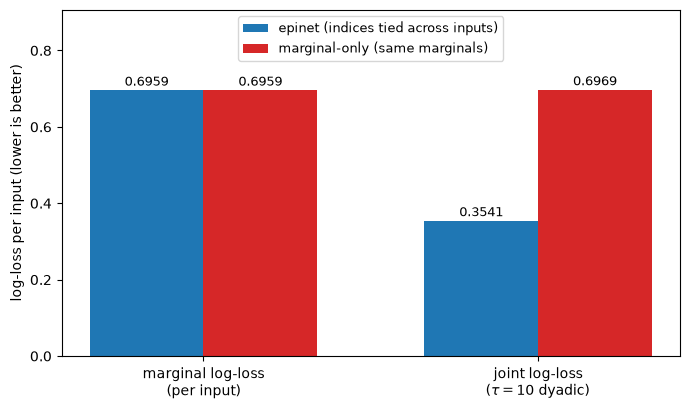

In [17]:
marginal_only = (
    torch.log(boundary_probs.mean(0) + 1e-12).unsqueeze(0).expand_as(boundary_logits).contiguous()
)

generator = torch.Generator().manual_seed(0)
targets = torch.multinomial(boundary_probs[0], 1, generator=generator).squeeze(-1)

scores = {}
for name, logits in [("epinet", boundary_logits), ("marginal-only", marginal_only)]:
    scores[name] = (
        float(marginal_log_loss(logits, targets)),
        float(
            joint_log_loss_dyadic(
                logits, targets, tau=10, kappa=2, num_batches=500,
                generator=torch.Generator().manual_seed(0),
            )
        ),
    )
    print(f"{name:>14}:  marginal {scores[name][0]:.4f}   joint (tau=10) {scores[name][1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(2)
width = 0.34
epi = scores["epinet"]
mrg = scores["marginal-only"]
bars = list(ax.bar(x - width / 2, epi, width, label="epinet (indices tied across inputs)", color="C0"))
bars += list(ax.bar(x + width / 2, mrg, width, label="marginal-only (same marginals)", color="C3"))
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
            f"{b.get_height():.4f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(["marginal log-loss\n(per input)", "joint log-loss\n($\\tau=10$ dyadic)"])
ax.set_ylabel("log-loss per input (lower is better)")
ax.set_ylim(0, max(epi + mrg) * 1.3)
ax.legend(loc="upper center", fontsize=9)
plt.tight_layout()
plt.show()

The marginal scores agree to four decimals, while the joint scores differ by roughly a factor of two. Two models that no per-input metric could separate are decisively separated once the predictions are scored together — which is the entire argument for joint evaluation.

A caveat on reading these numbers. The targets here are generated by the model itself (drawn from one of its own index samples), so this demonstrates *dependence between predictions*, not calibration or accuracy against real labels. The marginal-only baseline is a constructed straw man, not a trained competitor. For an honest comparison against real baselines on real labels, see the CIFAR-10 experiment in `experiments/epinet_cifar10/`, which scores epinet, deep ensembles and MC dropout on observed test labels.

`joint_log_loss_dyadic` reports log loss **per input** (joint loss divided by $\tau$). Compare methods at the same $\tau$, using the same observed targets and anchor draws.

## Joint Predictions on CIFAR-10

Two Moons is a toy problem with a self-generated labelling, so it can only illustrate the mechanism. The same evaluation on real data and observed labels lives in `experiments/epinet_cifar10/`, which trains a ResNet-18 base network on CIFAR-10 and then fits an epinet head on top of the **frozen** base, alongside a deep ensemble and MC dropout as baselines.

The cells below read the cached test-set logits that experiment writes (`run.py cache_logits`). They are skipped automatically when the file is absent, so this tutorial still builds without the experiment artifacts.

In [18]:
from pathlib import Path

CIFAR_LOGITS = Path("../../../results/epinet_cifar_reduced/test_logits.pt")
HAVE_CIFAR = CIFAR_LOGITS.exists()

if HAVE_CIFAR:
    cached = torch.load(CIFAR_LOGITS, weights_only=True)
    cifar_labels = cached["labels"]
    cifar_agents = {
        "single net": cached["ensemble"][:1].float(),
        "MC dropout": cached["dropout"].float(),
        "epinet": cached["epinet"].float(),
        "ensemble (3 members)": cached["ensemble"].float(),
    }
    for name, logits in cifar_agents.items():
        error = float((logits.softmax(-1).mean(0).argmax(-1) != cifar_labels).float().mean())
        print(f"{name:>22}: {logits.shape[0]:>2} samples   test error {error:.4f}")
else:
    print("Cached CIFAR-10 logits not found; skipping this section.")
    print("Generate them with: python experiments/epinet_cifar10/cifar/run.py cache_logits")

            single net:  1 samples   test error 0.0577
            MC dropout: 50 samples   test error 0.0566
                epinet: 50 samples   test error 0.0582
  ensemble (3 members):  3 samples   test error 0.0479


Because dyadic batches repeat their anchors, the number of inputs scored together, $\tau$, controls how much joint structure the metric can see. At $\tau = 1$ it reduces to the ordinary marginal log-loss and every method looks similar. Sweeping $\tau$ upward separates them.

In [19]:
if HAVE_CIFAR:
    taus = [1, 2, 3, 5, 10, 20, 30]
    seeds = range(8)
    curves = {}
    for name, logits in cifar_agents.items():
        curves[name] = [
            np.mean([
                float(joint_log_loss_dyadic(
                    logits, cifar_labels, tau=tau, kappa=2, num_batches=400,
                    generator=torch.Generator().manual_seed(seed),
                ))
                for seed in seeds
            ])
            for tau in taus
        ]
    print("computed joint log-loss over tau for", len(curves), "methods")

computed joint log-loss over tau for 4 methods


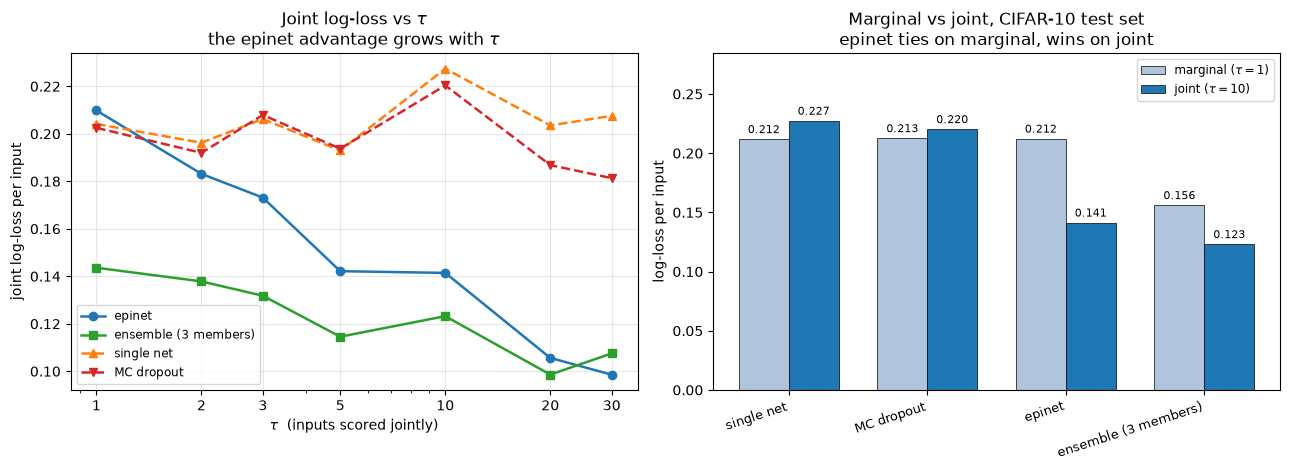

In [20]:
if HAVE_CIFAR:
    style = {
        "epinet": ("C0", "o", "-"),
        "ensemble (3 members)": ("C2", "s", "-"),
        "single net": ("C1", "^", "--"),
        "MC dropout": ("C3", "v", "--"),
    }
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    ax = axes[0]
    for name, (color, marker, ls) in style.items():
        ax.plot(taus, curves[name], color=color, marker=marker, ls=ls, lw=1.8, ms=6, label=name)
    ax.set_xscale("log")
    ax.set_xticks(taus)
    ax.set_xticklabels(taus)
    ax.set_xlabel("$\\tau$  (inputs scored jointly)")
    ax.set_ylabel("joint log-loss per input")
    ax.set_title("Joint log-loss vs $\\tau$\nthe epinet advantage grows with $\\tau$")
    ax.legend(fontsize=8.5)
    ax.grid(alpha=0.3)

    ax = axes[1]
    order = ["single net", "MC dropout", "epinet", "ensemble (3 members)"]
    marg = [float(marginal_log_loss(cifar_agents[n], cifar_labels)) for n in order]
    joint = [curves[n][taus.index(10)] for n in order]
    x = np.arange(len(order))
    width = 0.36
    ax.bar(x - width / 2, marg, width, label="marginal ($\\tau=1$)",
           color="lightsteelblue", edgecolor="k", lw=0.5)
    ax.bar(x + width / 2, joint, width, label="joint ($\\tau=10$)",
           color="C0", edgecolor="k", lw=0.5)
    for i, (a, b) in enumerate(zip(marg, joint)):
        ax.text(i - width / 2, a + 0.005, f"{a:.3f}", ha="center", fontsize=8)
        ax.text(i + width / 2, b + 0.005, f"{b:.3f}", ha="center", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=18, ha="right", fontsize=9)
    ax.set_ylabel("log-loss per input")
    ax.set_ylim(0, max(marg + joint) * 1.25)
    ax.legend(fontsize=8.5)
    ax.set_title("Marginal vs joint, CIFAR-10 test set\nepinet ties on marginal, wins on joint")
    plt.tight_layout()
    plt.show()

Two things to read off these plots.

The left panel shows the epinet starting in the same band as the single network and MC dropout at $\tau = 1$ and pulling away as $\tau$ grows. Its marginal predictions are unremarkable; the structure across predictions is what improves.

The right panel makes that explicit at $\tau = 10$. The epinet's marginal log-loss is essentially the single network's — it is scoring the same frozen base network, after all — while its joint log-loss is far lower, and it approaches the 3-member ensemble at a fraction of the cost: the trainable head adds about 0.33% to the base network's parameters, against the 3× of the ensemble.

One caveat on scope. This reduced run trains only 3 ensemble members. The ranking against that ensemble is itself $\tau$-dependent: it leads the epinet at $\tau = 10$ and the epinet overtakes it by $\tau = 30$. The paper's headline claim is stronger than either — that the epinet falls *below the entire ensemble curve*, which needs ensemble sizes up to 30 to test, and that is not reproduced here. See `results/epinet_cifar_reduced/SCOPE.md` for what this run does and does not establish.